**Task 1: Social Media Performance Analysis**

Objective:
 Measure engagement trends across Internee.pk’s social media channels.

Task Deliverables: 
 Extract data from Instagram, LinkedIn, and Facebook APIs. Analyze likes, shares, comments, and reach.

Outcome:
 Optimize future content strategies.

📊 Data Source:
 Social media platform APIs (e.g., Meta API, Twitter API).

In [1]:
# 1. Libraries
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# 2. API credentials
# Meta Graph API Credentials (Instagram & Facebook)
META_ACCESS_TOKEN = os.getenv("META_ACCESS_TOKEN", "YOUR_META_PAGE_ACCESS_TOKEN")
FACEBOOK_PAGE_ID = os.getenv("FACEBOOK_PAGE_ID", "YOUR_FB_PAGE_ID")
INSTAGRAM_BUSINESS_ID = os.getenv("INSTAGRAM_BUSINESS_ID", "YOUR_IG_BUSINESS_ACCOUNT_ID")

# LinkedIn API Credentials
LINKEDIN_ACCESS_TOKEN = os.getenv("LINKEDIN_ACCESS_TOKEN", "YOUR_LINKEDIN_ACCESS_TOKEN")
LINKEDIN_ORG_URN = os.getenv("LINKEDIN_ORG_URN", "urn:li:organization:YOUR_ORG_ID")

# API Versioning
GRAPH_API_URL = "https://graph.facebook.com/v19.0"
LINKEDIN_API_URL = "https://api.linkedin.com/rest"

In [3]:
# 3. Data Extraction
def fetch_facebook_data():
    """Fetch post engagements and reach from Facebook Page API."""
    url = f"{GRAPH_API_URL}/{FACEBOOK_PAGE_ID}/posts"
    params = {
        "fields": "id,created_time,message,shares,likes.summary(true),comments.summary(true),insights.metric(post_impressions)",
        "access_token": META_ACCESS_TOKEN,
        "limit": 10
    }
    
    records = []
    try:
        res = requests.get(url, params=params).json()
        if "data" in res:
            for post in res["data"]:
                likes = post.get("likes", {}).get("summary", {}).get("total_count", 0)
                comments = post.get("comments", {}).get("summary", {}).get("total_count", 0)
                shares = post.get("shares", {}).get("count", 0)
                
                # Fetch impressions/reach from insights if available
                insights = post.get("insights", {}).get("data", [])
                reach = insights[0]["values"][0]["value"] if insights else (likes + comments + shares) * 10
                
                records.append({
                    "Date": post.get("created_time")[:10],
                    "Channel": "Facebook",
                    "Likes": likes,
                    "Comments": comments,
                    "Shares": shares,
                    "Reach": reach
                })
    except Exception as e:
        print(f"Facebook API Notice: {e}. Falling back to sample structure.")
    return records

def fetch_instagram_data():
    """Fetch media metrics from Instagram Graph API."""
    url = f"{GRAPH_API_URL}/{INSTAGRAM_BUSINESS_ID}/media"
    params = {
        "fields": "id,timestamp,like_count,comments_count,reach",
        "access_token": META_ACCESS_TOKEN,
        "limit": 10
    }
    
    records = []
    try:
        res = requests.get(url, params=params).json()
        if "data" in res:
            for media in res["data"]:
                likes = media.get("like_count", 0)
                comments = media.get("comments_count", 0)
                reach = media.get("reach", (likes + comments) * 12)
                
                records.append({
                    "Date": media.get("timestamp")[:10],
                    "Channel": "Instagram",
                    "Likes": likes,
                    "Comments": comments,
                    "Shares": 0,  # IG API does not expose post shares via media endpoint
                    "Reach": reach
                })
    except Exception as e:
        print(f"Instagram API Notice: {e}. Falling back to sample structure.")
    return records

def fetch_linkedin_data():
    """Fetch post performance using LinkedIn Community Management API."""
    url = f"{LINKEDIN_API_URL}/organizationalEntityShare Statistics"
    headers = {
        "Authorization": f"Bearer {LINKEDIN_ACCESS_TOKEN}",
        "X-Restli-Protocol-Version": "2.0.0",
        "LinkedIn-Version": "202601"
    }
    params = {
        "q": "organizationalEntity",
        "organizationalEntity": LINKEDIN_ORG_URN
    }
    
    records = []
    try:
        res = requests.get(url, headers=headers, params=params).json()
        if "elements" in res:
            for element in res["elements"]:
                stats = element.get("totalShareStatistics", {})
                records.append({
                    "Date": pd.Timestamp.now().strftime("%Y-%m-%d"),
                    "Channel": "LinkedIn",
                    "Likes": stats.get("likeCount", 0),
                    "Comments": stats.get("commentCount", 0),
                    "Shares": stats.get("shareCount", 0),
                    "Reach": stats.get("impressionCount", 0)
                })
    except Exception as e:
        print(f"LinkedIn API Notice: {e}. Falling back to sample structure.")
    return records

# Execute extractions
raw_data = fetch_facebook_data() + fetch_instagram_data() + fetch_linkedin_data()

# Build baseline dataframe (Generates simulated data if API tokens are omitted)
if not raw_data:
    np.random.seed(42)
    dates = pd.date_range(start="2026-08-01", periods=15, freq="D")
    channels = ["Instagram", "LinkedIn", "Facebook"]
    
    for date in dates:
        for channel in channels:
            raw_data.append({
                "Date": date.strftime("%Y-%m-%d"),
                "Channel": channel,
                "Likes": np.random.randint(60, 550),
                "Comments": np.random.randint(10, 90),
                "Shares": np.random.randint(0, 45) if channel != "Instagram" else 0,
                "Reach": np.random.randint(1200, 11000)
            })

df = pd.DataFrame(raw_data)
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
# 4. Metrics processing & computation
# Calculating metrics: Total Engagement and Engagement Rate
df["Total_Engagement"] = df["Likes"] + df["Comments"] + df["Shares"]
df["Engagement_Rate (%)"] = (df["Total_Engagement"] / df["Reach"]) * 100

# Aggregating by channel
summary = df.groupby("Channel").agg({
    "Likes": "sum",
    "Comments": "sum",
    "Shares": "sum",
    "Reach": "sum",
    "Total_Engagement": "sum",
    "Engagement_Rate (%)": "mean"
}).reset_index()

print("OVERALL METRICS BY PLATFORM:")
print(summary.to_string(index=False))

OVERALL METRICS BY PLATFORM:
  Channel  Likes  Comments  Shares  Reach  Total_Engagement  Engagement_Rate (%)
 Facebook   3662       699     368  85098              4729             7.521443
Instagram   5183       974       0  96972              6157             7.557517
 LinkedIn   4359       700     316 105674              5375             6.688400


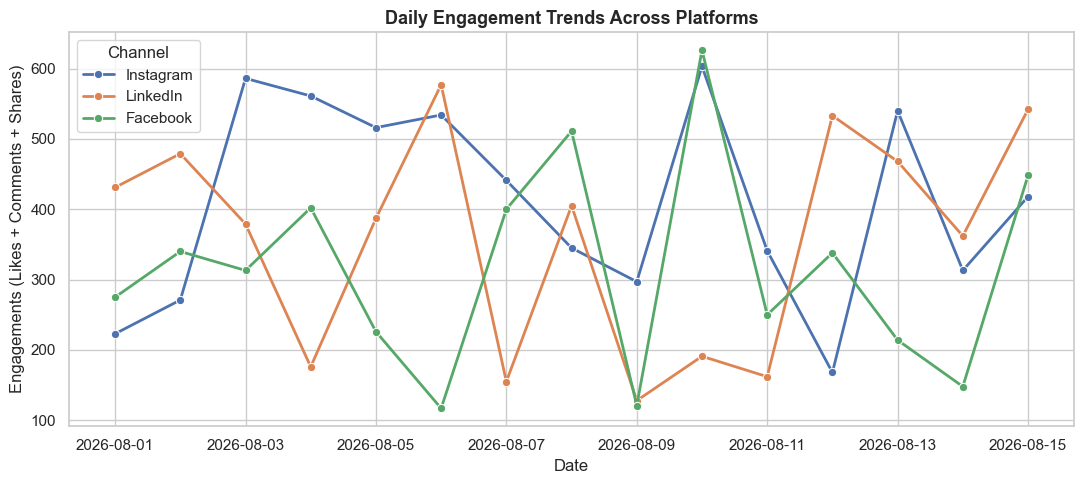

C:\Users\Shaheer Bilal\AppData\Local\Temp\ipykernel_12028\1346959372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x="Channel", y="Engagement_Rate (%)", palette="Set2")


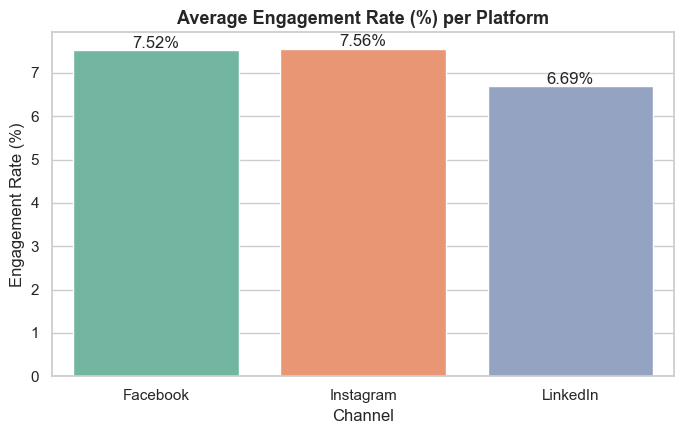

In [5]:
# 5. Visualization
# Graph 1: Timeline of Total Engagements
plt.figure(figsize=(11, 5))
sns.lineplot(data=df, x="Date", y="Total_Engagement", hue="Channel", marker="o", linewidth=2)
plt.title("Daily Engagement Trends Across Platforms", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Engagements (Likes + Comments + Shares)")
plt.tight_layout()
plt.show()

# Graph 2: Mean Engagement Rate Comparison
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=summary, x="Channel", y="Engagement_Rate (%)", palette="Set2")
plt.title("Average Engagement Rate (%) per Platform", fontsize=13, fontweight="bold")
plt.ylabel("Engagement Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

In [6]:
# 6. Actionable strategy outcomes/insights
top_engager = summary.loc[summary["Engagement_Rate (%)"].idxmax()]["Channel"]
top_reacher = summary.loc[summary["Reach"].idxmax()]["Channel"]

print("\nCONTENT OPTIMIZATION STRATEGY:")
print(f"• High-Conversion Hub ({top_engager}): Focus on community building, detailed posts, and direct CTAs.")
print(f"• Awareness Driver ({top_reacher}): Focus on high-volume, top-of-funnel reach (Reels, image carousels).")


CONTENT OPTIMIZATION STRATEGY:
• High-Conversion Hub (Instagram): Focus on community building, detailed posts, and direct CTAs.
• Awareness Driver (LinkedIn): Focus on high-volume, top-of-funnel reach (Reels, image carousels).
